Zadanie 2
Korzystając z metody akceptacji-odrzucenia, zaimplementuj generator liczb losowych z podanego rozkładu:
(1. rozkład dyskretyny o rozkładzie niestandardowym)

In [67]:
import numpy as np
import scipy as sc
import math
import matplotlib.pyplot as plt
import time

In [68]:
def acceptance_reject(p, x):
    p_y = 0.2
    c = 1.55
    while True:
        Y = math.floor(5 * np.random.random())
        U = np.random.random()
        if U <= p[Y]/(c*p_y):
            return x[Y]

2. Wygeneruj zmienną losową X z rozkładu Γ(α = 3, θ = 2) o gęstości:
$$ f(x) = \dfrac{1}{16}x^2e^{−\frac{x}{2}} , x > 0. $$


Najlepsza funkcja f to: $$ g(x) = \dfrac{1}{6}e^{-\frac{1}{6}x}$$

In [69]:
def g_exp_generate(lam):
    return np.random.exponential(scale=1/lam)

def g_exp(x, lam):
    return 0 if x < 0 else (lam) * np.exp(-x*lam)

def f_gamma(x):
    return 1/16 * x**2 * np.exp(-x/2)

def gamma_distr(x):
    return sc.stats.gamma.cdf(x, a=3, loc=0, scale=2)

def f_a(x):
    return 3/2*(1-x**2) if (0 <= x <= 1) else 0

def F_a(x):
    if x < 0: return 0
    if x < 1: return 1/2*(3*x - x**3)
    else: return 1

def uniform_generate(a, b):
    return np.random.uniform(low=a, high=b)

def uniform_densisty(x, a, b):
    return sc.stats.uniform.pdf(x, loc=a, scale=a+b)

def f_b(x):
    return 3/2*np.sin(x)*(np.cos(x))**2 if (0 <= x <= np.pi) else 0

def F_b(x):
    if x < 0: return 0
    if x < np.pi: return 1/2*(1 - np.cos(x)**3)
    return 1

def f_c(x):
    return 2*np.sqrt(1/(2*np.pi))*np.exp(-1/2*x**2)

def F_c(x):
    return sc.special.erf(x/np.sqrt(2)) if x > 0 else 0

def F_discrete(x):
    if x < 1:
        return 0
    if x < 2:
        return 0.11
    if x < 3:
        return 0.23
    if x < 4:
        return 0.50
    if x < 5:
        return 0.69
    return 1


In [70]:
def acc_rej_pdf(f, g, g_generate, c,):
    while True:
        y = g_generate()
        u = np.random.random()
        if u <= f(y) / (c * g(y)):
            return y

In [71]:
def drawdemp(X, title = 'Dystrybuanta empiryczna', ax=plt, color=None, label=None):
    X = np.sort(np.array(X))
    n = len(X)
    dx = 0.000001
    y = np.linspace(1/n, 1, n)
    y = np.repeat(y, 2)
    x = np.empty(2*n)
    x[0::2] = X
    x[1::2] = X + dx
    y[1::2] += 1/n
    y[2*n-1] -= 1/n
    ax.plot(x, y, color=color, label=label)
    if ax == plt:
        ax.title(title)
    else:
        ax.set_title(title)

In [72]:
def rev_distr(F, t, a = -100000, b = 100000, dx = 1e-3):
    while b - a > dx:
        x = 0.5 * (a + b)
        diff = F(x) - t
        if diff > 0:
            b = x
        else:
            a = x
    return 0.5 * (a + b)

In [73]:
def rev_discrete_distr(F, t, a = -100000, b = 100000, dx = 1e-3):
    x = (a + b) // 2
    while b - a > 1:
        x = (a + b) // 2
        diff = F(x) - t
        if diff > 0:
            b = x
        else:
            a = x
    return b

In [74]:
def drawqq(X, distr, title='QQ Plot', bound_a = -1e5, bound_b=1e5, dx=1e-3, ax=plt, rev_distr=rev_distr):
    X = np.sort(X)
    n = len(X)
    Q = np.empty(n)
    for i in range(1, n):
        q = rev_distr(distr, i / n, a = bound_a, b = bound_b, dx=dx)
        Q[i-1] = q
    Q[n - 1] = rev_distr(distr, 1 - 0.5 / n, a = bound_a, b = bound_b, dx=dx)
    ax.plot(Q, X, 'go', markersize=2)
    a, b = np.polyfit(Q, X, 1)
    x_line = np.linspace(min(Q), max(Q), n)
    ax.plot(x_line, a * x_line + b, 'r-')
    if ax == plt:
        ax.title(title)
    else:
        ax.set_title(title)

In [75]:
def test(x_theory, y_dens, y_distr, x, F, a, b, dx=1e-3, distribution='Not defined', time='None', accuracy=3):
    fig, axes = plt.subplots(1, 3, figsize=(12, 6))
    fig.suptitle(f'Metoda akceptacji/odrzucenia dla rozkładu {distribution}')
    axes[0].hist(x, bins=200, density=True)
    axes[0].plot(x_theory, y_dens)
    axes[0].set_title('Wykres gęstości')
    drawdemp(x, ax=axes[1])
    axes[1].plot(x_theory, y_distr)
    drawqq(x, distr=F, bound_a=a, bound_b=b, dx=dx, ax=axes[2])
    plt.show()
    
    var = np.var(x)
    mean = np.median(x)

    print(f'Wariancja wynosi: {round(var, accuracy)}, wartość średnia: {round(mean, accuracy)}.')
    if time != 'None':
        print(f'Czas potrzebny na wygenerowanie {len(x)} próbek wyniósł {round(time, accuracy)}')

### Generowanie rozkładów do zadania 2.
1. Rozkład dyskretny

Rozkład z podpunktu a):


E(X) = 3,47, Var(X) = 1,77


Rozkład z podpunktu b):

$$ \alpha = 3,\quad \theta = 2 $$

$$ E(X) = \alpha \cdot \theta = 6,\quad Var(X) = \alpha \cdot \theta^2 = 12 $$

Wariancja wynosi: 1.8046959999999999, wartość średnia: 3.448.


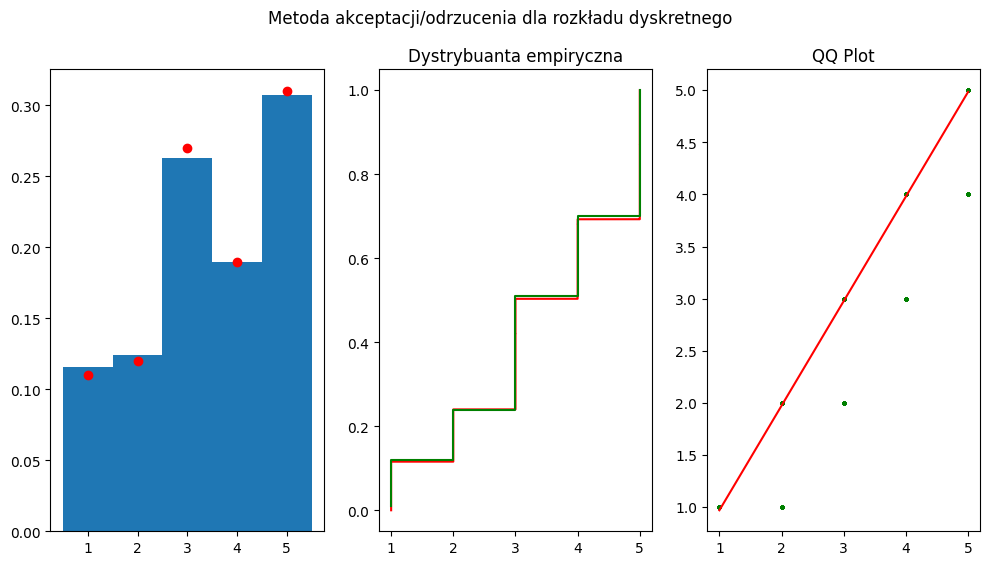

In [93]:
p_values = [1, 2, 3, 4, 5]
p_prob = [0.11, 0.12, 0.27, 0.19, 0.31]
Y = []
N = 10000
t = np.empty(N)
for i in range(N):
    t[i] = acceptance_reject(p_prob, p_values)


fig, axes = plt.subplots(1, 3, figsize=(12, 6))
fig.suptitle(f'Metoda akceptacji/odrzucenia dla rozkładu dyskretnego')
axes[0].hist(t, bins=np.arange(0.5, 6.5, 1), density=True)
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].plot(p_values, p_prob, 'ro')

Y_theory = np.empty(100)
s = 0

for p in range(len(p_prob)):
    for k in range(int(p_prob[p]*100)):
        Y_theory[s] = p_values[p]
        s += 1
    
drawdemp(t, ax=axes[1], color='red')
drawdemp(Y_theory, ax=axes[1], color='green')
drawqq(t, F_discrete, bound_a=0, bound_b=6, dx=1, ax=axes[2], rev_distr=rev_discrete_distr)
print(f'Wariancja wynosi: {np.var(t)}, wartość średnia: {np.mean(t)}.')
plt.show()

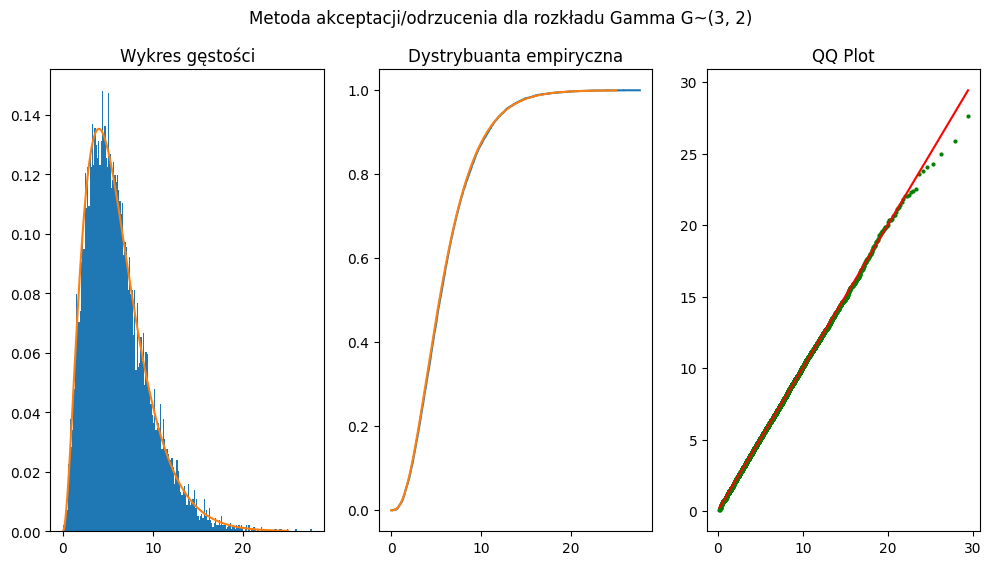

Wariancja wynosi: 11.95, wartość średnia: 5.425.
Czas potrzebny na wygenerowanie 10000 próbek wyniósł 0.038


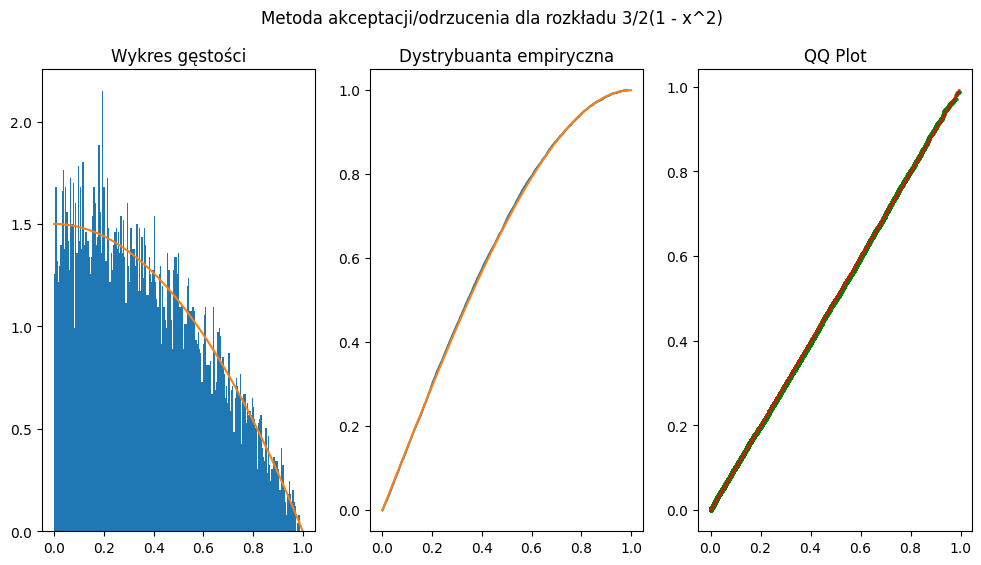

Wariancja wynosi: 0.059, wartość średnia: 0.343.
Czas potrzebny na wygenerowanie 10000 próbek wyniósł 0.536


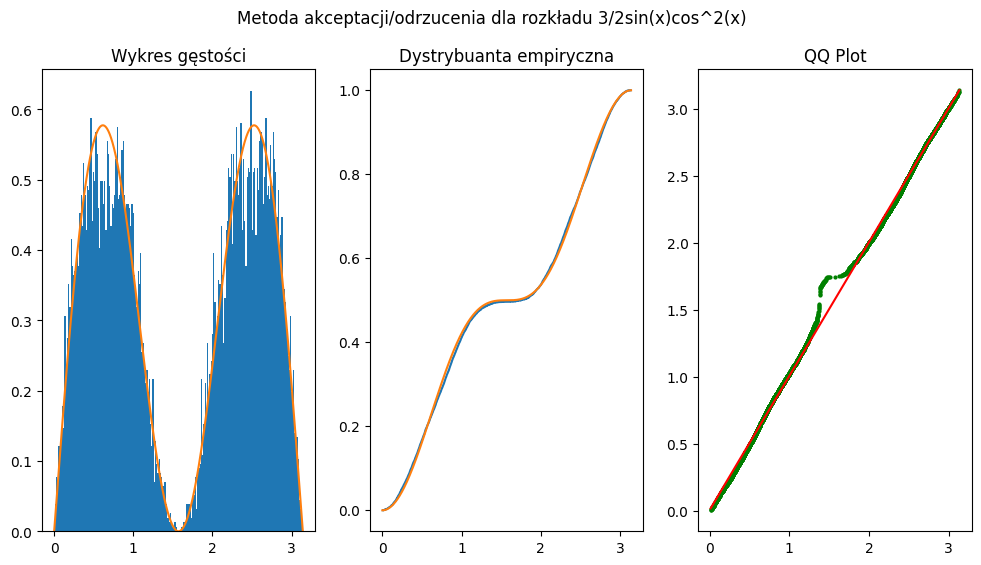

Wariancja wynosi: 0.91, wartość średnia: 1.751.
Czas potrzebny na wygenerowanie 10000 próbek wyniósł 0.597


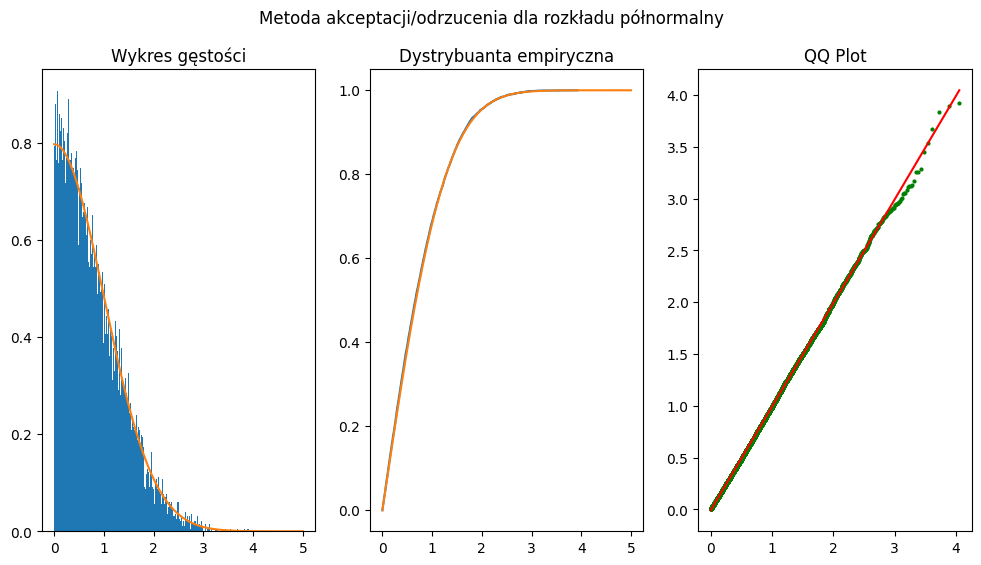

Wariancja wynosi: 0.364, wartość średnia: 0.661.
Czas potrzebny na wygenerowanie 10000 próbek wyniósł 0.044


In [94]:
N = 10000
f = 1/16
c = 27/2*np.exp(-2)

x_gamma = np.empty(N)
x_gamma_theory = np.linspace(0, 25, N)
y_gamma_distr = gamma_distr(x_gamma_theory)
y_gamma_dens = []

for x in x_gamma_theory:
    y_gamma_dens.append(f_gamma(x))

t1 = time.perf_counter()

for i in range(N):
    x_gamma[i] = acc_rej_pdf(f_gamma, lambda x: g_exp(x, 1/6), lambda: g_exp_generate(1/6), c)

t_total = time.perf_counter() - t1

test(x_gamma_theory, y_gamma_dens, y_gamma_distr, x_gamma, gamma_distr, 0, 30, 1e-2, 'Gamma G~(3, 2)', time=t_total)

x_a = np.empty(N)
x_a_theory = np.linspace(0, 1, N)
y_a_distr = []
y_a_dens = []

for x in x_a_theory:
    y_a_dens.append(f_a(x))
    y_a_distr.append(F_a(x))

u_denstity_a = lambda x: uniform_densisty(x, 0, 1)
u_gen_a = lambda: uniform_generate(0, 1)
u_denstity_b = lambda x: uniform_densisty(x, 0, np.pi)
u_gen_b = lambda: uniform_generate(0, np.pi)

t1 = time.perf_counter()
for i in range(N):
    x_a[i] = acc_rej_pdf(f_a, u_denstity_a, u_gen_a, 3/2)

t_total = time.perf_counter() - t1
test(x_a_theory, y_a_dens, y_a_distr, x_a, F_a, 0, 1, distribution='3/2(1 - x^2)', time=t_total)

x_b = np.empty(N)
x_b_theory = np.linspace(0, np.pi, N)
y_b_distr = []
y_b_dens = []
for x in x_b_theory:
    y_b_distr.append(F_b(x))
    y_b_dens.append(f_b(x))

t1 = time.perf_counter()
for i in range(N):
    x_b[i] = acc_rej_pdf(f_b, u_denstity_b, u_gen_b, 3/2)

t_total = time.perf_counter() - t1
test(x_b_theory, y_b_dens, y_b_distr, x_b, F_b, 0, np.pi, distribution='3/2sin(x)cos^2(x)', time=t_total)

x_c = np.empty(N)
x_c_theory = np.linspace(0, 5, N)
y_c_distr = []
y_c_dens = []
for x in x_c_theory:
    y_c_distr.append(F_c(x))
    y_c_dens.append(f_c(x))

t1 = time.perf_counter()
for i in range(N):
    x_c[i] = acc_rej_pdf(f_c, lambda x: g_exp(x, 1), lambda: g_exp_generate(1), np.sqrt(2/np.pi) * np.exp(1/2))

t_total = time.perf_counter() - t1
test(x_c_theory, y_c_dens, y_c_distr, x_c, F_c, 0, 5, distribution='półnormalny', time=t_total)



### Generowanie zmiennnej z rozkładu normalnego N(0, 1) metodą Boxa-Mullera

Zadanie 4, 5

In [ ]:
def box_muller(size=2):
    s = size // 2
    U1 = np.random.uniform(size=s)
    U2 = np.random.uniform(size=s)
    X = np.sqrt(-2 * np.log(U1)) * np.cos(2 * np.pi * U2)
    Y = np.sqrt(-2 * np.log(U1)) * np.sin(2 * np.pi * U2)
    return np.concatenate([X, Y])

def box_muller_polar(size=2):
    if size % 2 == 1:
        size += 1
    
    s = int(size / 2 * 1.4)
    U1 = np.random.uniform(-1, 1, size=s)
    U2 = np.random.uniform(-1, 1, size=s)
    R2 = U1**2 + U2**2

    mask = (0 < R2) & (R2 < 1)
    U1 = U1[mask]
    U2 = U2[mask]
    R2 = R2[mask]
    M = np.sqrt(-2*np.log(R2) / R2)
    X = U1 * M
    Y = U2 * M

    accepted = 2 * len(R2)
    N_samples = np.empty(max(accepted, size))
    N_samples[0::2] = X
    N_samples[1::2] = Y

    if accepted >= size:
        return N_samples[:size]
    
    while accepted < size:
        U1 = np.random.uniform(-1, 1)
        U2 = np.random.uniform(-1, 1)
        R2 = U1**2 + U2**2
        if 0 < R2 < 1:
            X = U1 * np.sqrt(-2 * np.log(R2) / R2)
            Y = U2 * np.sqrt(-2 * np.log(R2) / R2)
            N_samples[accepted] = X
            N_samples[accepted + 1] = Y
            accepted += 2

    return N_samples


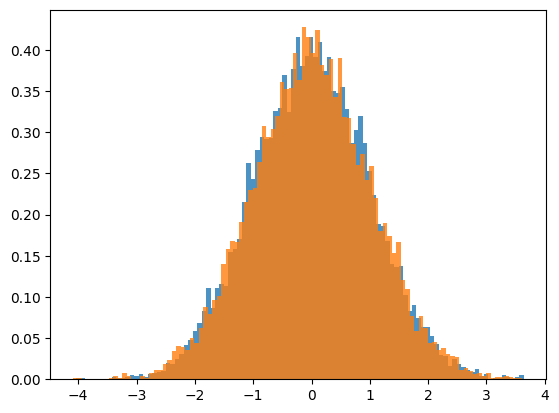

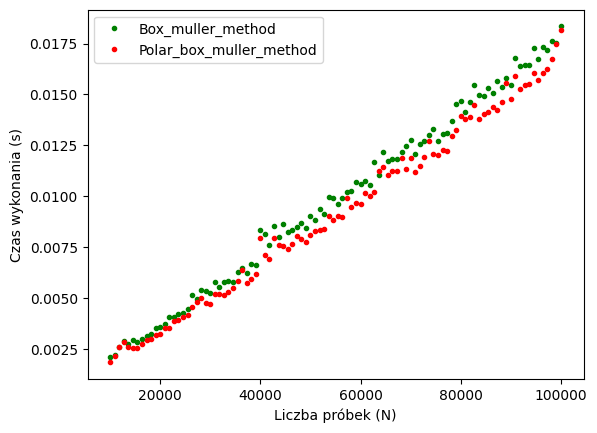

In [86]:
N = 10000
X_1 = box_muller(N)
X_2 = box_muller_polar(N)

plt.hist(X_1, bins=100, density=True, alpha=0.8)
plt.hist(X_2, bins=100, density=True, alpha=0.8)
plt.show()

N_n = np.linspace(1e4, 1e5, 100)
repetition = 10

Y1 = []
Y2 = []

for n in N_n:
    s1 = 0.0
    s2 = 0.0
    for r in range(repetition):
        t1_begin = time.perf_counter()
        X_1 = box_muller(int(n))
        t1_end = time.perf_counter()
        s1 += t1_end - t1_begin

        t2_begin = time.perf_counter()
        X_2 = box_muller_polar(int(n))
        t2_end = time.perf_counter()
        s2 += t2_end - t2_begin

    Y1.append(s1)
    Y2.append(s2)

plt.plot(N_n, Y1, 'go', markersize=3, label='Box_muller_method')
plt.plot(N_n, Y2, 'ro', markersize=3, label='Polar_box_muller_method')
plt.xlabel('Liczba próbek (N)')
plt.ylabel('Czas wykonania (s)')
plt.legend()
plt.show()


### Zadanie 6
Macierz kowariancji

In [87]:
def covariance_matrix(N, relation):
    COV_matrix = np.zeros((N, N))
    p = 0
    
    for i in range(N):
        COV_matrix[i][i] = 1
        for k in range(i):
            COV_matrix[k][i] = relation[p]
            COV_matrix[i][k] = relation[p]
            p += 1
            
    return COV_matrix

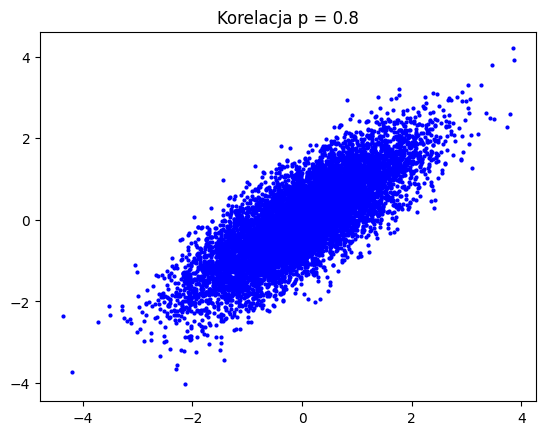

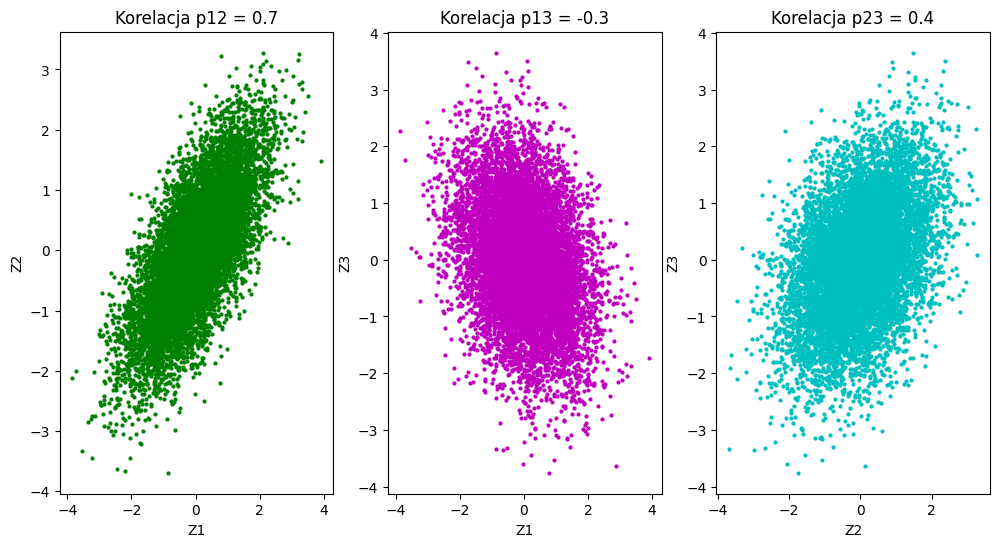

In [88]:
p = 0.8
N = 10000

A1 = covariance_matrix(2, [p])
L1 = np.linalg.cholesky(A1)
X1 = np.random.normal(0, 1, size=N)
X2 = np.random.normal(0, 1, size=N)
X = np.array([X1, X2])
Z = L1 @ X

Z1 = Z[0]
Z2 = Z[1]

plt.plot(Z1, Z2, 'bo', markersize=2)
plt.title(f'Korelacja p = {p}')
plt.show()

p12 = 0.7
p13 = -0.3
p23 = 0.4
A2 = covariance_matrix(3, [p12, p13, p23])
L2 = np.linalg.cholesky(A2)
X1 = np.random.normal(0, 1, size=N)
X2 = np.random.normal(0, 1, size=N)
X3 = np.random.normal(0, 1, size=N)
X = np.array([X1, X2, X3])
Z = L2 @ X
Z1, Z2, Z3 = Z

fig, axes = plt.subplots(1, 3, figsize=(12, 6))
axes[0].plot(Z1, Z2, 'go', markersize=2)
axes[0].set_xlabel('Z1')
axes[0].set_ylabel('Z2')
axes[0].set_title(f'Korelacja p12 = {p12}')
axes[1].plot(Z1, Z3, 'mo', markersize=2)
axes[1].set_xlabel('Z1')
axes[1].set_ylabel('Z3')
axes[1].set_title(f'Korelacja p13 = {p13}')
axes[2].plot(Z2, Z3, 'co', markersize=2)
axes[2].set_xlabel('Z2')
axes[2].set_ylabel('Z3')
axes[2].set_title(f'Korelacja p23 = {p23}')
plt.show()




### Zadanie 7

1. Aproksymacja liczby pi
2. Aproksymacja całki

In [89]:
def pi(N):
    U1 = np.random.uniform(low=-1, high=1, size=N)
    U2 = np.random.uniform(low=-1, high=1, size=N)
    R2 = U1**2 + U2**2
    accepted = np.sum(R2 <= 1)
    return 4 * accepted / N

def exp_x2(x):
    return np.exp(-x**2)

def integral(bound_a=0, bound_b=1, dx=1e-3):
    x = np.arange(bound_a, bound_b, dx)
    s = np.sum(exp_x2(x)) * dx
    return s
    

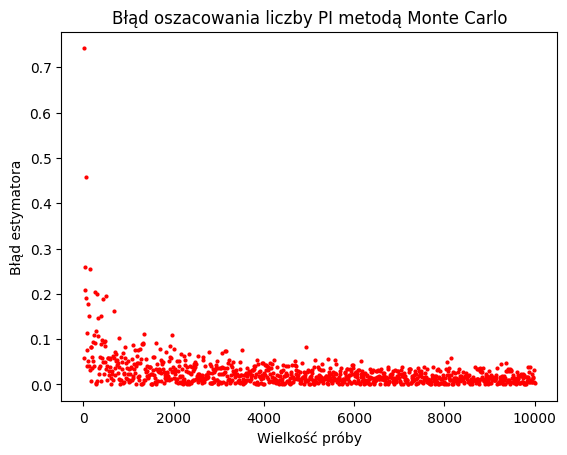

Wartość oszacowanej całki: 0.7468272934090899, wartość z biblioteki scipy: 0.7468241328124271.


In [90]:
set_N = np.linspace(10, 10000, 1000)
Y = []

PI = np.pi

for n in set_N:
    s = 0
    s += pi(int(n))
    Y.append(abs(PI - s))

plt.plot(set_N, Y, 'ro', markersize=2)
plt.title('Błąd oszacowania liczby PI metodą Monte Carlo')
plt.xlabel('Wielkość próby')
plt.ylabel('Błąd estymatora')
plt.show()

integral_ex2 = integral(dx=1e-5)
integral_scipy = sc.integrate.quad(func=exp_x2, a=0, b=1)
print(f'Wartość oszacowanej całki: {integral_ex2}, wartość z biblioteki scipy: {integral_scipy[0]}.')